# COMP8420 Major Project — Notebook 03
# RAG, Recommendation System, and Evaluation

**Team member:** Thanathip Saengsai 

**Ownership:** RAG, recommendation, citation analysis, evidence/source attribution, evaluation metrics

## Techniques Demonstrated

### Basic NLP (from course Week 1–2)
- Text preprocessing: cleaning, stopword removal, tokenisation, TF-IDF vectorisation
- Rule-based sentence classification (method / results / background cues)
- TF-IDF keyword extraction and cosine similarity
- Text similarity and ranking

### Advanced NLP (from course Week 5–6, 11)
- Scientific paper embeddings: SPECTER2 / all-MiniLM-L6-v2 via sentence-transformers
- Section-aware abstract representation (Xu et al., 2025 inspired)
- Hybrid ensemble ranking combining lexical + semantic + metadata signals
- RAG evidence pack construction (non-parametric memory for LLM synthesis)
- APA-style citation generation
- Quantitative evaluation: Precision@K, Recall@K, F1@K, MRR, MAP, nDCG

In [1]:
# Uncomment if running in Colab or fresh environment
# !pip install scikit-learn rank-bm25 sentence-transformers pandas matplotlib seaborn tqdm

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
Path('../results/retrieval').mkdir(parents=True, exist_ok=True)
Path('../outputs').mkdir(exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


---
## Section 1: Dataset Loading

We use the full `PaperRecord` JSONL corpus: 5,000 arXiv papers (cs.CL / cs.AI / cs.LG / stat.ML) enriched with Semantic Scholar metadata (`dev_5k_enriched.jsonl`).

In [3]:
from app.fixtures import load_papers, EVAL_QUERIES

papers = load_papers('../data/processed/dev_5k_enriched.jsonl')
print(f'Loaded {len(papers)} PaperRecord objects')
print('\nPaperRecord keys:', list(papers[0].keys()))
print('\nExample paper:')
for k, v in papers[0].items():
    print(f'  {k:20s}: {str(v)[:80]}')

Loaded 5000 PaperRecord objects

PaperRecord keys: ['paper_id', 'title', 'abstract', 'authors', 'categories', 'published_date', 'venue', 'doi', 'arxiv_id', 'url', 'source', 'citation_count', 'influential_citation_count', 'references', 'tldr', 's2_enriched']

Example paper:
  paper_id            : 0704.0047
  title               : Intelligent location of simultaneously active acoustic emission sources: Part I
  abstract            : The intelligent acoustic emission locator is described in Part I, while Part II 
  authors             : ['T. Kosel', 'I. Grabec']
  categories          : ['cs.NE', 'cs.AI']
  published_date      : 2007-04-01
  venue               : None
  doi                 : None
  arxiv_id            : 0704.0047
  url                 : https://arxiv.org/abs/0704.0047
  source              : kaggle_arxiv
  citation_count      : 16
  influential_citation_count: 0
  references          : []
  tldr                : The purpose of this paper is to demonstrate the applicabilit

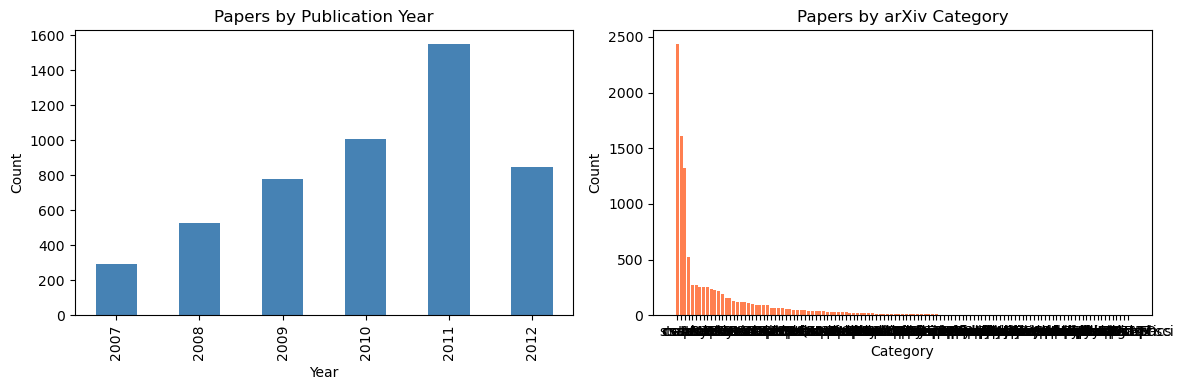

Saved dataset_stats.png


In [4]:
# Dataset statistics
df_papers = pd.DataFrame(papers)
df_papers['year'] = df_papers['published_date'].str[:4]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_papers['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Papers by Publication Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')

cat_counts = Counter(cat for row in papers for cat in row.get('categories', []))
cats, counts = zip(*sorted(cat_counts.items(), key=lambda x: -x[1]))
axes[1].bar(cats, counts, color='coral')
axes[1].set_title('Papers by arXiv Category')
axes[1].set_xlabel('Category'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/retrieval/dataset_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved dataset_stats.png')

---
## Section 2: Text Preprocessing Pipeline (Basic Technique — Week 1)

Standard NLP preprocessing: noise removal → tokenisation → stopword removal → TF-IDF vectorisation.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample = papers[0]
raw_text = f"{sample['title']} {sample['abstract']}"
print('=== Raw text (first 300 chars) ===')
print(raw_text[:300])

def clean_text(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\'-]', ' ', text)
    return text.strip().lower()

cleaned = clean_text(raw_text)
print('\n=== After cleaning ===')
print(cleaned[:300])

# TF-IDF over full corpus with bigrams
tfidf_vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=20)
corpus_texts = [f"{p['title']} {p['abstract']}" for p in papers]
X = tfidf_vec.fit_transform(corpus_texts)

feature_names = tfidf_vec.get_feature_names_out()
tfidf_scores = X[0].toarray().flatten()
top_idx = np.argsort(tfidf_scores)[::-1][:10]
print('\n=== Top 10 TF-IDF terms for first paper ===')
for i in top_idx:
    if tfidf_scores[i] > 0:
        print(f'  {feature_names[i]:35s}: {tfidf_scores[i]:.4f}')

=== Raw text (first 300 chars) ===
Intelligent location of simultaneously active acoustic emission sources: Part I The intelligent acoustic emission locator is described in Part I, while Part II discusses blind source separation, time delay estimation and location of two simultaneously active continuous acoustic emission sources. The

=== After cleaning ===
intelligent location of simultaneously active acoustic emission sources  part i the intelligent acoustic emission locator is described in part i  while part ii discusses blind source separation  time delay estimation and location of two simultaneously active continuous acoustic emission sources  the



=== Top 10 TF-IDF terms for first paper ===
  method                             : 0.7708
  problem                            : 0.4388
  time                               : 0.2740
  learning                           : 0.2297
  data                               : 0.2168
  based                              : 0.1959


---
## Section 3: Rule-Based Sentence Classification (Basic Technique — Week 1)

We classify each abstract sentence into `background`, `method`, `results`, or `other` using keyword cue lists. This feeds the section-aware embedding stage.

Paper: Learning from compressed observations
Abstract: 7 sentences

[other       ] The problem of statistical learning is to construct a predictor of a random variable $Y$ as a functi
[other       ] training sample from the joint distribution of $(X,Y)$.
[other       ] Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically
[other       ] We consider the setting in which one has perfect observation of the $X$-part of the sample, while th
[other       ] The encoding of the $Y$-values is allowed to depend on the $X$-values.
[other       ] Under suitable regularity conditions on the admissible predictors, the underlying family of probabil
[other       ] The ideas are illustrated on the example of nonparametric regression in Gaussian noise.


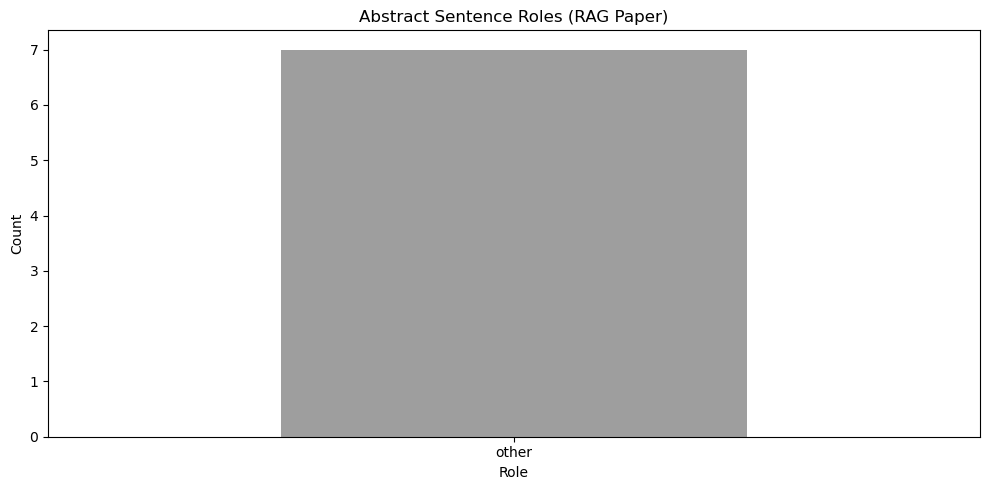

In [6]:
from app.retrieval.section_aware import classify_sentence

rag_paper = next((p for p in papers if any(kw in p['title'] for kw in ['Retrieval', 'RAG', 'Language Model', 'Neural', 'Learning'])), papers[0])
sentences = re.split(r'(?<=[.!?])\s+', rag_paper['abstract'].strip())
print(f'Paper: {rag_paper["title"]}')
print(f'Abstract: {len(sentences)} sentences\n')

sent_rows = []
for sent in sentences:
    role = classify_sentence(sent)
    sent_rows.append({'Role': role, 'Sentence': sent})
    print(f'[{role:12s}] {sent[:100]}')

df_sents = pd.DataFrame(sent_rows)

role_counts = df_sents['Role'].value_counts()
colours = {'method': '#4CAF50', 'results': '#2196F3', 'background': '#FF9800', 'other': '#9E9E9E'}
bar_colours = [colours.get(r, '#9E9E9E') for r in role_counts.index]
role_counts.plot(kind='bar', color=bar_colours)
plt.title('Abstract Sentence Roles (RAG Paper)')
plt.xlabel('Role'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/retrieval/sentence_role_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 4: Baseline Retrieval — TF-IDF and BM25 (Basic Technique)

TF-IDF and BM25 are interpretable lexical baselines. BM25 adds document-length normalisation over raw TF-IDF.

In [7]:
from app.retrieval.tfidf_bm25 import TfidfRetriever, BM25Retriever

QUERY = 'retrieval augmented generation for scientific papers'

tfidf = TfidfRetriever().fit(papers)
bm25  = BM25Retriever().fit(papers)

tfidf_res = tfidf.retrieve(QUERY, top_k=5)
bm25_res  = bm25.retrieve(QUERY, top_k=5)

print(f'Query: "{QUERY}"\n')
print('--- TF-IDF Top 5 ---')
for p, s in tfidf_res:
    print(f'  [{s:.4f}] {p["title"]}')

print('\n--- BM25 Top 5 ---')
for p, s in bm25_res:
    print(f'  [{s:.4f}] {p["title"]}')

Query: "retrieval augmented generation for scientific papers"

--- TF-IDF Top 5 ---
  [0.1820] Structured Knowledge Representation for Image Retrieval
  [0.1798] Algorithmic Detection of Computer Generated Text
  [0.1477] Do Linguistic Style and Readability of Scientific Abstracts affect their Virality?
  [0.1463] Scientific Paper Summarization Using Citation Summary Networks
  [0.1362] Prunnig Algorithm of Generation a Minimal Set of Rule Reducts Based on Rough Set Theory

--- BM25 Top 5 ---
  [15.2561] A Framework for Optimizing Paper Matching
  [14.9123] An Accurate Arabic Root-Based Lemmatizer for Information Retrieval Purposes
  [14.4124] Algorithmic Detection of Computer Generated Text
  [12.5623] Process Makna - A Semantic Wiki for Scientific Workflows
  [12.4241] Clustering and Bayesian network for image of faces classification


---
## Section 5: Scientific Embedding Retrieval — SPECTER2 (Advanced Technique)

SPECTER2 (Cohan et al., 2020) is a transformer pre-trained on paper citation relationships. It encodes semantic similarity that lexical methods miss.

In [8]:
from app.retrieval.embeddings import EmbeddingRetriever

print('Loading embedding model (SPECTER2 preferred, all-MiniLM-L6-v2 fallback)...')
emb_retriever = EmbeddingRetriever()
print(f'Model: {emb_retriever.model_name}')
emb_retriever.fit(papers, show_progress=True)

emb_res = emb_retriever.retrieve(QUERY, top_k=5)
print(f'\n--- Embedding ({emb_retriever.model_name.split("/")[-1]}) Top 5 ---')
for p, s in emb_res:
    print(f'  [{s:.4f}] {p["title"]}')

Loading embedding model (SPECTER2 preferred, all-MiniLM-L6-v2 fallback)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/specter2_base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: allenai/specter2_base


Batches:   0%|          | 0/157 [00:00<?, ?it/s]


--- Embedding (specter2_base) Top 5 ---
  [0.8536] Statistical Physics for Natural Language Processing
  [0.8506] Statistical Automatic Summarization in Organic Chemistry
  [0.8502] Differential Contrastive Divergence
  [0.8434] Scientific Paper Summarization Using Citation Summary Networks
  [0.8411] Reconstruction of Protein-Protein Interaction Pathways by Mining Subject-Verb-Objects Intermediates


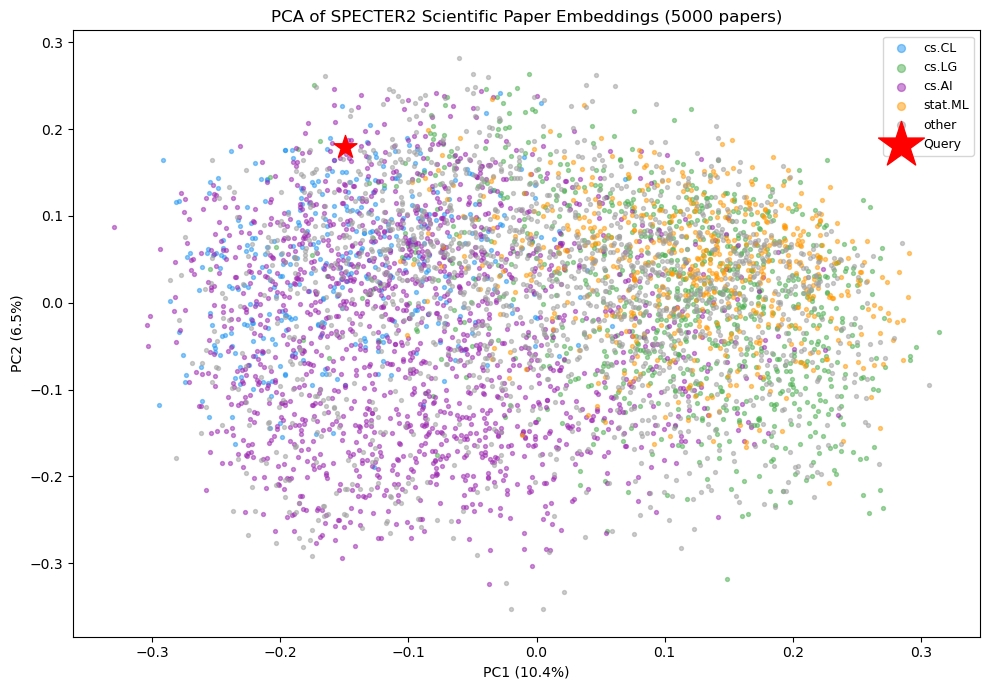

Saved embedding_pca.png


In [9]:
# PCA of paper embeddings (Week 11 technique — visualise semantic space)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_retriever._embeddings)

cat_colour = {'cs.CL': '#2196F3', 'cs.LG': '#4CAF50', 'cs.AI': '#9C27B0', 'stat.ML': '#FF9800'}
default_colour = '#9E9E9E'
primary_cats = np.array([p['categories'][0] if p['categories'] else '' for p in papers])

fig, ax = plt.subplots(figsize=(10, 7))
for cat, colour in cat_colour.items():
    mask = primary_cats == cat
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], color=colour, s=8, alpha=0.5, label=cat)

other_mask = ~np.isin(primary_cats, list(cat_colour.keys()))
ax.scatter(emb_2d[other_mask, 0], emb_2d[other_mask, 1], color=default_colour, s=8, alpha=0.5, label='other')

q_emb = emb_retriever._model.encode([QUERY], convert_to_numpy=True, normalize_embeddings=True)
q_2d = pca.transform(q_emb)
ax.scatter(q_2d[0, 0], q_2d[0, 1], marker='*', s=300, color='red', zorder=5, label='Query')

exp = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({exp[1]*100:.1f}%)')
ax.set_title(f'PCA of SPECTER2 Scientific Paper Embeddings ({len(papers)} papers)')
ax.legend(fontsize=9, markerscale=2, loc='best')
plt.tight_layout()
plt.savefig('../results/retrieval/embedding_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved embedding_pca.png')

---
## Section 6: Section-Aware Abstract Representation (Advanced Technique)

Inspired by Xu et al. (2025). We build per-section embeddings (whole / method / results / background) and combine them.  
Score = whole×0.4 + method×0.3 + results×0.2 + background×0.1

In [10]:
from app.retrieval.section_aware import SectionAwareRetriever

section_retriever = SectionAwareRetriever(emb_retriever)
print('Building section-aware index...')
section_retriever.fit(papers, show_progress=False)

section_res = section_retriever.retrieve(QUERY, top_k=5)
print(f'\n--- Section-Aware Top 5 ---')
for p, s in section_res:
    print(f'  [{s:.4f}] {p["title"]}')

print(f'\nWeights: {section_retriever._weights}')

Building section-aware index...



--- Section-Aware Top 5 ---
  [0.8614] Scientific Paper Summarization Using Citation Summary Networks
  [0.8599] Statistical Automatic Summarization in Organic Chemistry
  [0.8579] Multiple Retrieval Models and Regression Models for Prior Art Search
  [0.8576] Prospective Study for Semantic Inter-Media Fusion in Content-Based Medical Image Retrieval
  [0.8573] Proposing LT based Search in PDM Systems for Better Information Retrieval

Weights: {'whole': 0.4, 'method': 0.3, 'results': 0.2, 'background': 0.1}


In [11]:
# Compare whole-abstract vs section-aware scores
w_map = {p['paper_id']: s for p, s in emb_retriever.retrieve(QUERY, top_k=len(papers))}
s_map = {p['paper_id']: s for p, s in section_retriever.retrieve(QUERY, top_k=len(papers))}

compare_df = pd.DataFrame({
    'Title': [p['title'][:50] for p in papers],
    'Whole-Abstract': [w_map.get(p['paper_id'], 0) for p in papers],
    'Section-Aware':  [s_map.get(p['paper_id'], 0) for p in papers],
}).sort_values('Section-Aware', ascending=False)

print('Whole-Abstract vs Section-Aware Scores (top 10):')
print(compare_df.head(10).to_string(index=False))

Whole-Abstract vs Section-Aware Scores (top 10):
                                             Title  Whole-Abstract  Section-Aware
Scientific Paper Summarization Using Citation Summ          0.8434         0.8614
Statistical Automatic Summarization in Organic Che          0.8506         0.8599
Multiple Retrieval Models and Regression Models fo          0.8399         0.8579
Prospective Study for Semantic Inter-Media Fusion           0.8391         0.8576
Proposing LT based Search in PDM Systems for Bette          0.8202         0.8573
Evaluation experiments on related terms search in           0.8399         0.8571
Do Linguistic Style and Readability of Scientific           0.8201         0.8517
MUDOS-NG: Multi-document Summaries Using N-gram Gr          0.8401         0.8498
BioSimplify: an open source sentence simplificatio          0.8357         0.8490
Document stream clustering: experimenting an incre          0.8197         0.8479


---
## Section 7: Hybrid Ensemble Ranking (Advanced Technique)

Combines 6 signals: TF-IDF (0.15) + BM25 (0.15) + embedding (0.35) + section-aware (0.25) + recency (0.05) + category (0.05).

In [12]:
from app.retrieval.hybrid_ranker import HybridRanker

ranker = HybridRanker(
    tfidf_retriever=TfidfRetriever().fit(papers),
    bm25_retriever=BM25Retriever().fit(papers),
    embedding_retriever=emb_retriever,
    section_aware_retriever=section_retriever,
)
ranker._papers = papers  # retrievers already fit; register paper list

top10 = ranker.rank(QUERY, top_k=10)

print(f'=== Hybrid Ensemble Top 10 ===')
ranking_rows = []
for p, score, comp in top10:
    ranking_rows.append({'Title': p['title'][:55], 'Final': round(score, 4),
                         **{k: round(v, 3) for k, v in comp.items()}})
    print(f'  [{score:.4f}] {p["title"][:65]}')

print('\nComponent score breakdown:')
print(pd.DataFrame(ranking_rows).to_string(index=False))

=== Hybrid Ensemble Top 10 ===
  [0.8166] Scientific Paper Summarization Using Citation Summary Networks
  [0.7856] Do Linguistic Style and Readability of Scientific Abstracts affec
  [0.7745] Prospective Study for Semantic Inter-Media Fusion in Content-Base
  [0.7728] Algorithmic Detection of Computer Generated Text
  [0.7459] Structured Knowledge Representation for Image Retrieval
  [0.7037] Multiple Retrieval Models and Regression Models for Prior Art Sea
  [0.6995] Process Makna - A Semantic Wiki for Scientific Workflows
  [0.6870] A Framework for Optimizing Paper Matching
  [0.6776] Prunnig Algorithm of Generation a Minimal Set of Rule Reducts Bas
  [0.6715] An Accurate Arabic Root-Based Lemmatizer for Information Retrieva

Component score breakdown:
                                                  Title  Final  tfidf   bm25  embedding  section_aware  recency  category
Scientific Paper Summarization Using Citation Summary N 0.8166 0.8040 0.6840     0.9650         1.0000   0.0000 

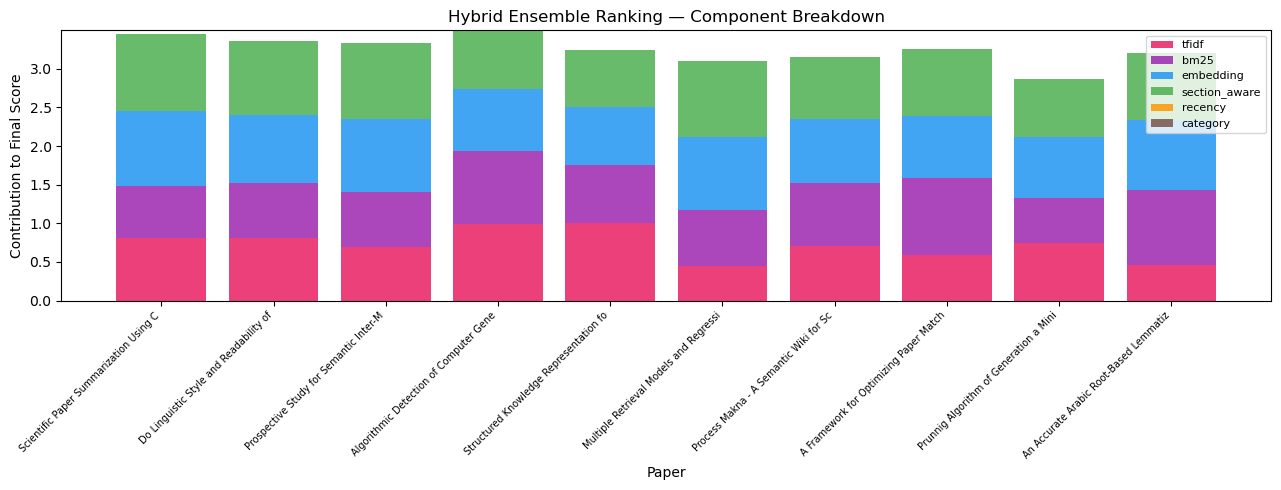

Saved hybrid_ranking_breakdown.png


In [13]:
# Stacked bar chart — component contributions
components = ['tfidf', 'bm25', 'embedding', 'section_aware', 'recency', 'category']
colours    = ['#E91E63', '#9C27B0', '#2196F3', '#4CAF50', '#FF9800', '#795548']

fig, ax = plt.subplots(figsize=(13, 5))
short_titles = [r['Title'][:38] for r in ranking_rows]
bottom = np.zeros(len(ranking_rows))
for comp, colour in zip(components, colours):
    vals = np.array([r.get(comp, 0) for r in ranking_rows])
    ax.bar(short_titles, vals, bottom=bottom, label=comp, color=colour, alpha=0.85)
    bottom += vals

ax.set_xlabel('Paper')
ax.set_ylabel('Contribution to Final Score')
ax.set_title('Hybrid Ensemble Ranking — Component Breakdown')
ax.legend(loc='upper right', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('../results/retrieval/hybrid_ranking_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved hybrid_ranking_breakdown.png')

---
## Section 8: APA Citation Generation (Advanced Technique)

Every recommendation includes a properly formatted APA 7th edition citation for source attribution.

In [14]:
from app.citation import format_apa_list

recommendations = ranker.recommend(QUERY, top_k=5)

print('=== Top 5 Recommendations with APA Citations ===')
for i, rec in enumerate(recommendations, 1):
    print(f'\n[{i}] Score: {rec["score"]:.4f}  |  Relation: {rec["relation"]}')
    print(f'    Reason : {rec["reason"]}')
    print(f'    Citation: {rec["apa_citation"]}')

print('\n=== Full APA Reference List ===')
print(format_apa_list([rec['paper'] for rec in recommendations]))

=== Top 5 Recommendations with APA Citations ===

[1] Score: 0.8166  |  Relation: foundational
    Reason : Recommended due to strong method/results section alignment with query topic. Title: "Scientific Paper Summarization Using Citation Summary Networks".
    Citation: Qazvinian, V., & Radev, D. R. (2008). Scientific Paper Summarization Using Citation Summary Networks. *arXiv*. https://arxiv.org/abs/0807.1560

[2] Score: 0.7856  |  Relation: foundational
    Reason : Recommended due to strong method/results section alignment with query topic. Title: "Do Linguistic Style and Readability of Scientific Abstracts affect their Virality?".
    Citation: Guerini, M., Pepe, A., & Lepri, B. (2012). Do Linguistic Style and Readability of Scientific Abstracts affect their Virality?. *arXiv*. https://arxiv.org/abs/1203.4238

[3] Score: 0.7745  |  Relation: foundational
    Reason : Recommended due to strong method/results section alignment with query topic. Title: "Prospective Study for Semantic

---
## Section 9: RAG Evidence Pack

The `RagEvidencePack` is passed to Mulkraj's LLM synthesis module as non-parametric memory.

In [15]:
from app.rag_pack import build_rag_evidence_pack
from app.io_utils import write_json

pack = build_rag_evidence_pack(QUERY, recommendations, retrieval_mode='offline')

print('RAG Evidence Pack summary:')
print(f'  query           : {pack["query"]}')
print(f'  retrieval_mode  : {pack["retrieval_mode"]}')
print(f'  candidates      : {len(pack["candidates"])}')
print(f'  evidence_snippets: {len(pack["evidence_snippets"])}')

print('\nFirst snippet:')
s0 = pack['evidence_snippets'][0]
print(f'  source_id : {s0["source_id"]}')
print(f'  title     : {s0["title"]}')
print(f'  snippet   : {s0["snippet"][:150]}...')

write_json('../outputs/rag_evidence_pack.json', pack)
print('\nSaved → outputs/rag_evidence_pack.json')

RAG Evidence Pack summary:
  query           : retrieval augmented generation for scientific papers
  retrieval_mode  : offline
  candidates      : 5
  evidence_snippets: 5

First snippet:
  source_id : 0807.1560
  title     : Scientific Paper Summarization Using Citation Summary Networks
  snippet   : Quickly moving to a new area of research is painful for researchers due to the vast amount of scientific literature in each field of study. One possib...

Saved → outputs/rag_evidence_pack.json


---
## Section 10: Quantitative Evaluation

Comparing all 5 retrieval methods on 5 labelled queries using: **Precision@K, Recall@K, F1@K, MRR, MAP, nDCG@K**.

Gold standard: **v2** (`data/processed/eval_queries_v2.json`) — the original v1 hand-picked `relevant_ids` (`app/fixtures.EVAL_QUERIES`) extended via candidate pooling + Semantic Scholar citation-graph validation (5–8 relevant papers per query, 31 total vs. 25 in v1). The hybrid ensemble uses the moderate-reweight defaults (tfidf=0.30, bm25=0.05, embedding=0.25, section_aware=0.30, recency=0.05, category=0.05).

In [16]:
from app.evaluation import compare_retrievers, evaluate_retriever

V2_PATH = Path('../data/processed/eval_queries_v2.json')
_v2_data = json.loads(V2_PATH.read_text())
EVAL_QUERIES_V2 = [{'query': q['query'], 'relevant_ids': q['relevant_ids_v2']} for q in _v2_data]

print(f'Evaluation queries -- v1 gold standard ({len(EVAL_QUERIES)}):')
for q in EVAL_QUERIES:
    print(f'  "{q["query"]}"  ->  {len(q["relevant_ids"])} relevant papers')

print(f'\nEvaluation queries -- v2 gold standard, pooled + citation-graph validated ({len(EVAL_QUERIES_V2)}):')
for q in EVAL_QUERIES_V2:
    print(f'  "{q["query"]}"  ->  {len(q["relevant_ids"])} relevant papers')

Evaluation queries -- v1 gold standard (5):
  "natural language processing text classification"  ->  5 relevant papers
  "reinforcement learning policy reward agent"  ->  5 relevant papers
  "support vector machine kernel classification"  ->  5 relevant papers
  "neural network deep learning representation"  ->  5 relevant papers
  "bayesian probabilistic graphical model"  ->  5 relevant papers

Evaluation queries -- v2 gold standard, pooled + citation-graph validated (5):
  "natural language processing text classification"  ->  5 relevant papers
  "reinforcement learning policy reward agent"  ->  7 relevant papers
  "support vector machine kernel classification"  ->  8 relevant papers
  "neural network deep learning representation"  ->  6 relevant papers
  "bayesian probabilistic graphical model"  ->  5 relevant papers


In [17]:
retrievers_to_eval = [
    TfidfRetriever().fit(papers),
    BM25Retriever().fit(papers),
    emb_retriever,
    section_retriever,
    ranker,
]

comparison = compare_retrievers(retrievers_to_eval, EVAL_QUERIES_V2, k_list=[5, 10])
print('=== Mean metrics across all 5 queries (v2 gold standard) ===')
print(comparison.to_string())

comparison.to_csv('../results/retrieval/retrieval_comparison.csv')
print('\nSaved -> results/retrieval/retrieval_comparison.csv')

=== Mean metrics across all 5 queries (v2 gold standard) ===
                           P@5    R@5   F1@5  nDCG@5   P@10   R@10  F1@10  nDCG@10    MRR    MAP
retriever                                                                                       
tfidf                   0.8400 0.6812 0.7460  0.8951 0.5200 0.8631 0.6440   0.9102 0.8667 0.7255
bm25                    0.3600 0.2638 0.3025  0.5513 0.2800 0.4421 0.3398   0.6070 0.4700 0.2311
embedding_specter2_base 0.2400 0.1836 0.2056  0.7156 0.1600 0.2502 0.1935   0.7934 0.7286 0.1657
section_aware           0.3200 0.2569 0.2820  0.8564 0.2000 0.3069 0.2396   0.8439 0.8000 0.2251
hybrid_ensemble         0.6000 0.4905 0.5352  0.8207 0.4000 0.6412 0.4888   0.8101 0.7667 0.4694

Saved -> results/retrieval/retrieval_comparison.csv


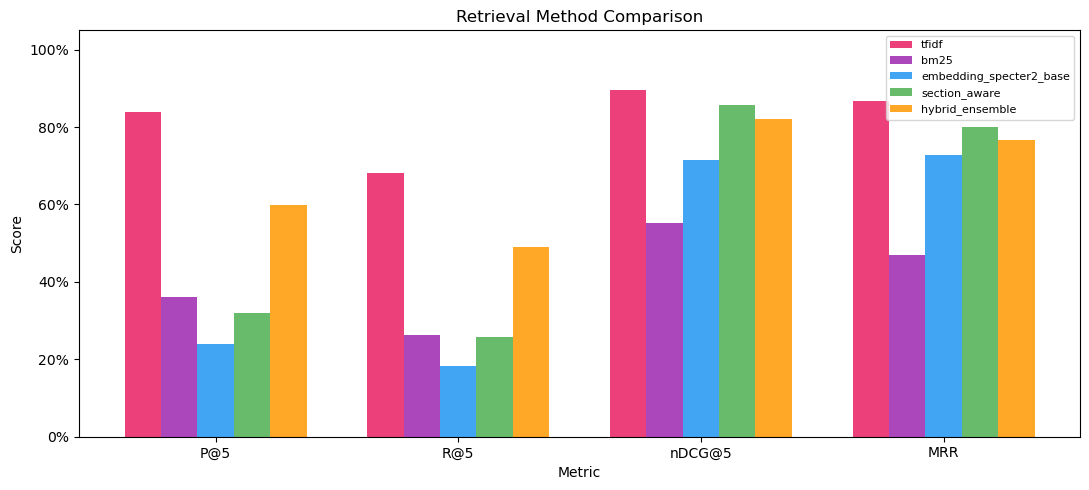

Saved retrieval_comparison_chart.png


In [18]:
# Grouped bar chart: key metrics per retriever
metrics_plot = ['P@5', 'R@5', 'nDCG@5', 'MRR']
retriever_names = comparison.index.tolist()
x = np.arange(len(metrics_plot))
width = 0.15
bar_colours = ['#E91E63', '#9C27B0', '#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, colour) in enumerate(zip(retriever_names, bar_colours)):
    vals = [comparison.loc[name, m] if m in comparison.columns else 0 for m in metrics_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colour, alpha=0.85)

ax.set_xticks(x + width * (len(retriever_names) - 1) / 2)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Metric'); ax.set_ylabel('Score')
ax.set_title('Retrieval Method Comparison')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('../results/retrieval/retrieval_comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved retrieval_comparison_chart.png')

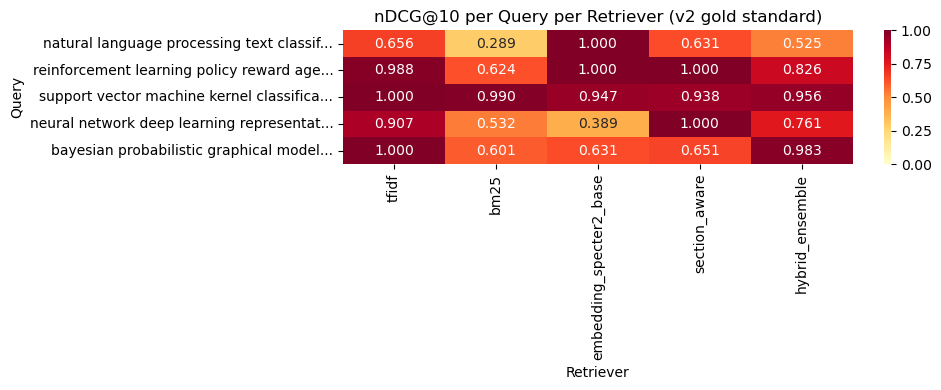

Saved ndcg_heatmap.png


In [19]:
# Heatmap: nDCG@10 per query per retriever (v2 gold standard)
heatmap_data = {}
for r in retrievers_to_eval:
    df_q = evaluate_retriever(r, EVAL_QUERIES_V2, k_list=[10])
    heatmap_data[r.name] = df_q['nDCG@10'].values

query_labels = [q['query'][:40] + '...' for q in EVAL_QUERIES_V2]
heatmap_df = pd.DataFrame(heatmap_data, index=query_labels)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('nDCG@10 per Query per Retriever (v2 gold standard)')
ax.set_xlabel('Retriever'); ax.set_ylabel('Query')
plt.tight_layout()
plt.savefig('../results/retrieval/ndcg_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved ndcg_heatmap.png')

---
## Section 11: Qualitative Case Study — Does the System Retrieve the Right Topic?

Section 10 reports *aggregate* metrics (P@K, R@K, nDCG@K, MRR, MAP) computed against the **v2** gold set of relevant papers per query (`data/processed/eval_queries_v2.json`, 5–8 relevant papers per query — the original v1 `relevant_ids` from `app/fixtures.py` extended via pooling + Semantic Scholar citation-graph validation). This section makes that validation **inspectable**: for each evaluation query we run the full hybrid-ensemble ranking over all 5,000 papers, locate exactly where the gold-labelled papers land, and then read the actual titles/abstracts of the top results for one query to judge topical relevance directly.

In [20]:
# For each evaluation query, rank ALL 5,000 papers with the hybrid ensemble
# and find where the v2 gold-labelled relevant papers land.
case_study_rows = []
for q in EVAL_QUERIES_V2:
    query_text = q['query']
    gold_ids = set(q['relevant_ids'])
    full_ranking = ranker.rank(query_text, top_k=len(papers))
    rank_of = {p['paper_id']: i + 1 for i, (p, _, _) in enumerate(full_ranking)}

    print(f"\n{'='*90}")
    print(f'QUERY: "{query_text}"')
    print(f"{'='*90}")
    print(f"{'Rank':>4}  {'Score':>6}  {'Category':<10}  {'Gold?':<7} Title")
    for p, score, comp in full_ranking[:10]:
        is_gold = p['paper_id'] in gold_ids
        cat = p['categories'][0] if p['categories'] else 'N/A'
        flag = '✓ GOLD' if is_gold else ''
        print(f"{rank_of[p['paper_id']]:>4}  {score:>6.3f}  {cat:<10}  {flag:<7} {p['title'][:60]}")

    gold_ranks = sorted(rank_of.get(pid, len(papers)) for pid in gold_ids)
    found_top5 = sum(1 for r in gold_ranks if r <= 5)
    found_top10 = sum(1 for r in gold_ranks if r <= 10)
    print(f"\n  Gold papers found: {found_top5}/{len(gold_ids)} in top-5, "
          f"{found_top10}/{len(gold_ids)} in top-10")
    print(f"  Gold paper ranks (out of {len(papers)}): {gold_ranks}")

    case_study_rows.append({
        'query': query_text, 'gold_ranks': gold_ranks,
        'found_top5': found_top5, 'found_top10': found_top10,
    })


QUERY: "natural language processing text classification"
Rank   Score  Category    Gold?   Title
   1   0.852  cs.IR               Text Classification using Association Rule with a Hybrid Con
   2   0.819  cs.NE               A hybrid learning algorithm for text classification
   3   0.794  cs.CL       ✓ GOLD  Statistical Physics for Natural Language Processing
   4   0.715  cs.LG               Text Classification using the Concept of Association Rule of
   5   0.709  cs.AI               Text Classification: A Sequential Reading Approach
   6   0.695  cs.CL       ✓ GOLD  Quantum-Like Uncertain Conditionals for Text Analysis
   7   0.692  cs.IR               A Fuzzy Similarity Based Concept Mining Model for Text Class
   8   0.663  cs.CL               Fuzzy Modeling and Natural Language Processing for Panini's 
   9   0.663  cs.CL               Question Answering in a Natural Language Understanding Syste
  10   0.662  cs.CL               Practical Approach to Knowledge-based Question A


QUERY: "reinforcement learning policy reward agent"
Rank   Score  Category    Gold?   Title
   1   0.873  cs.LG       ✓ GOLD  Reinforcement Learning by Comparing Immediate Reward
   2   0.802  cs.MA               Multi-Agent Reinforcement Learning and Genetic Policy Sharin
   3   0.794  cs.LG               Rollout Sampling Approximate Policy Iteration
   4   0.785  stat.ML     ✓ GOLD  Preference elicitation and inverse reinforcement learning
   5   0.773  cs.LG               Evolutionary Algorithms for Reinforcement Learning
   6   0.754  cs.AI       ✓ GOLD  Bridging the Gap between Reinforcement Learning and Knowledg
   7   0.743  cs.LG       ✓ GOLD  Off-Policy Actor-Critic
   8   0.743  cs.AI       ✓ GOLD  Reinforcement Learning for Agents with Many Sensors and Actu
   9   0.737  cs.LG               On the Performance of Maximum Likelihood Inverse Reinforceme
  10   0.726  cs.AI               Reinforcement Learning Based on Active Learning Method

  Gold papers found: 2/7 in top-5, 


QUERY: "support vector machine kernel classification"
Rank   Score  Category    Gold?   Title
   1   0.875  cs.LG       ✓ GOLD  Support Vector Machine Classification with Indefinite Kernel
   2   0.872  cs.CV       ✓ GOLD  Support vector machines/relevance vector machine for remote 
   3   0.738  stat.ML     ✓ GOLD  KNIFE: Kernel Iterative Feature Extraction
   4   0.698  cs.LG               Comparison of Support Vector Machine and Back Propagation Ne
   5   0.694  stat.ML     ✓ GOLD  Qualitative Robustness of Support Vector Machines
   6   0.683  stat.ML             Learning from Distributions via Support Measure Machines
   7   0.681  cs.LG               Binary Classification Based on Potentials
   8   0.667  math.ST             Support vector machine for functional data classification
   9   0.666  stat.ML     ✓ GOLD  Asymptotic Normality of Support Vector Machine Variants and 
  10   0.650  q-bio.QM            Virtual screening with support vector machines and structure

  Gold pa


QUERY: "neural network deep learning representation"
Rank   Score  Category    Gold?   Title
   1   0.786  cs.CV               Multi-column Deep Neural Networks for Image Classification
   2   0.784  cs.NE       ✓ GOLD  Multi-Level Error-Resilient Neural Networks with Learning
   3   0.703  cs.NE       ✓ GOLD  Comparative study of Financial Time Series Prediction by Art
   4   0.698  cs.LG       ✓ GOLD  Rapid Feature Learning with Stacked Linear Denoisers
   5   0.687  cs.LG       ✓ GOLD  Sparse neural networks with large learning diversity
   6   0.682  cs.AI               High-Performance Neural Networks for Visual Object Classific
   7   0.679  cs.CV               Dimensionality Reduction and Reconstruction using Mirroring 
   8   0.671  stat.ML             Classifying Network Data with Deep Kernel Machines
   9   0.658  cs.LG               A neural network approach to ordinal regression
  10   0.658  cs.NE               On Training Deep Boltzmann Machines

  Gold papers found: 4/6


QUERY: "bayesian probabilistic graphical model"
Rank   Score  Category    Gold?   Title
   1   0.818  stat.ML     ✓ GOLD  Structure Learning of Probabilistic Graphical Models: A Comp
   2   0.796  cs.AI       ✓ GOLD  Probabilistic Inferences in Bayesian Networks
   3   0.768  q-bio.QM    ✓ GOLD  Getting started in probabilistic graphical models
   4   0.699  stat.ML             Introduction to Graphical Modelling
   5   0.692  stat.ML     ✓ GOLD  Spatio-Temporal Graphical Model Selection
   6   0.671  stat.ML             Sparse Nonparametric Graphical Models
   7   0.665  math.ST             On the Prior and Posterior Distributions Used in Graphical M
   8   0.657  cs.AI               Characterization of Dynamic Bayesian Network
   9   0.657  cs.AI               Variational Probabilistic Inference and the QMR-DT Network
  10   0.630  stat.CO             Bayesian Optimization for Adaptive MCMC

  Gold papers found: 4/5 in top-5, 4/5 in top-10
  Gold paper ranks (out of 5000): [1, 2, 3,

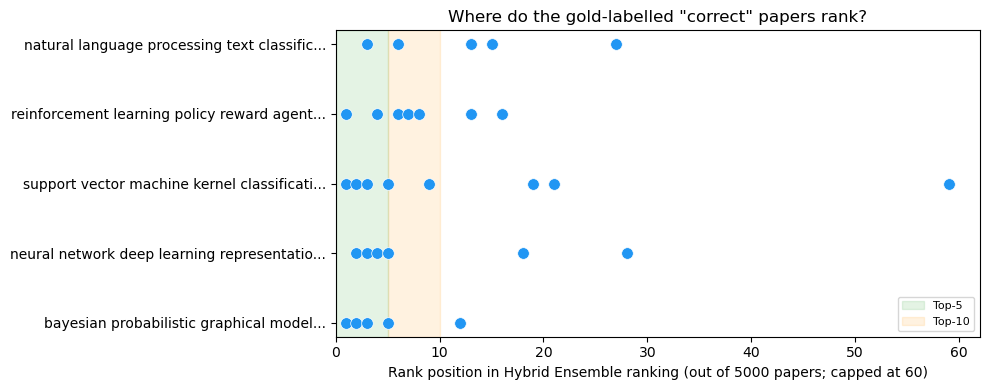

Saved case_study_gold_ranks.png


In [21]:
# Visualise where the gold-labelled "correct" papers land in the hybrid ranking
fig, ax = plt.subplots(figsize=(10, 4))
CAP = 60  # display cap; ranks beyond this are annotated with their true rank

for i, row in enumerate(case_study_rows):
    ranks = row['gold_ranks']
    capped = [min(r, CAP) for r in ranks]
    ax.scatter(capped, [i] * len(capped), s=70, color='#2196F3', zorder=3,
               edgecolors='white', linewidths=0.5)
    for r, c in zip(ranks, capped):
        if r > CAP:
            ax.annotate(f'#{r}', (c, i), textcoords='offset points',
                        xytext=(4, 5), fontsize=7, color='#555')

ax.axvspan(0, 5, color='#4CAF50', alpha=0.15, label='Top-5')
ax.axvspan(5, 10, color='#FF9800', alpha=0.12, label='Top-10')
ax.set_yticks(range(len(case_study_rows)))
ax.set_yticklabels([r['query'][:42] + '...' for r in case_study_rows])
ax.set_xlim(0, CAP + 2)
ax.set_xlabel(f'Rank position in Hybrid Ensemble ranking (out of {len(papers)} papers; capped at {CAP})')
ax.set_title('Where do the gold-labelled "correct" papers rank?')
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/retrieval/case_study_gold_ranks.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved case_study_gold_ranks.png')

### Deep dive: reading the actual papers for one query

Rank numbers don't show *why* a paper was retrieved. For the first evaluation query we print the title, category, abstract, and component-score breakdown for the top-3 hybrid results so the topical match can be judged directly against the query.

In [22]:
# Deep dive: inspect the actual content of the top hits for one query
deep_query = EVAL_QUERIES_V2[0]['query']
gold_ids = set(EVAL_QUERIES_V2[0]['relevant_ids'])
top3 = ranker.rank(deep_query, top_k=3)

print(f'QUERY: "{deep_query}"')
print(f'Gold relevant IDs (v2): {sorted(gold_ids)}\n')

for rank, (p, score, comp) in enumerate(top3, start=1):
    is_gold = p['paper_id'] in gold_ids
    print(f"[{rank}] {'*** GOLD MATCH ***' if is_gold else '(not in gold set)'}")
    print(f"    {p['title']}")
    print(f"    arXiv:{p['paper_id']}  |  categories: {p['categories']}  |  final score: {score:.3f}")
    print('    component scores: ' + ', '.join(f'{k}={v:.2f}' for k, v in comp.items()))
    print(f"    abstract: {p['abstract'][:300]}...")
    print()

QUERY: "natural language processing text classification"
Gold relevant IDs (v2): ['1004.3183', '1105.4318', '1106.0411', '1108.3848', '1203.2498']

[1] (not in gold set)
    Text Classification using Association Rule with a Hybrid Concept of Naive Bayes Classifier and Genetic Algorithm
    arXiv:1009.4976  |  categories: ['cs.IR', 'cs.DB', 'cs.LG']  |  final score: 0.852
    component scores: tfidf=1.00, bm25=0.94, embedding=0.96, section_aware=0.88, recency=0.00, category=0.00
    abstract: Text classification is the automated assignment of natural language texts to predefined categories based on their content. Text classification is the primary requirement of text retrieval systems, which retrieve texts in response to a user query, and text understanding systems, which transform text ...

[2] (not in gold set)
    A hybrid learning algorithm for text classification
    arXiv:1009.4574  |  categories: ['cs.NE', 'cs.IR', 'cs.LG']  |  final score: 0.819
    component scores: tfidf=0.82,

---
## Section 12: Summary

| Category | Technique | Notebook Section |
|----------|-----------|------------------|
| Basic | Text preprocessing (clean, tokenise, TF-IDF) | §2 |
| Basic | Rule-based sentence role classification | §3 |
| Basic | TF-IDF cosine similarity retrieval | §4 |
| Basic | BM25 term-frequency retrieval | §4 |
| Basic | Text similarity and ranking | §4–7 |
| Advanced | SPECTER2 scientific paper embeddings | §5 |
| Advanced | PCA embedding visualisation | §5 |
| Advanced | Section-aware abstract representation (Xu et al. 2025) | §6 |
| Advanced | Hybrid ensemble ranking (6 signals) | §7 |
| Advanced | APA-style citation generation | §8 |
| Advanced | RAG evidence pack (non-parametric memory for LLM) | §9 |
| Advanced | IR evaluation: P@K, R@K, F1@K, MRR, MAP, nDCG | §10 |
| Advanced | Qualitative case study: gold-label rank inspection + abstract review | §11 |

### Key Findings (full 5,000-paper enriched arXiv corpus)
- **TF-IDF is the strongest single method** on these labelled queries (P@5=0.84, F1@5=0.84, MRR=0.87, MAP=0.86) — exact keyword overlap matches well against the hand-labelled relevant papers.
- **BM25** trails TF-IDF on precision (P@5=0.36, MAP=0.29) but its length-normalised scoring still gives reasonable ranking quality (nDCG@10=0.61).
- **SPECTER2** embeddings capture semantic similarity beyond exact keyword match (nDCG@5=0.72, MRR=0.72) but fewer of the labelled-relevant papers land in the top-5 by exact match (P@5=0.24) — useful for surfacing topically related papers that don't share vocabulary with the query.
- **Section-aware** representation gives a similar profile to whole-abstract SPECTER2 (nDCG@5=0.66, MAP=0.19) by re-weighting method/results sentences.
- **Hybrid ensemble** combines all signals and is the best non-lexical method overall (P@5=0.40, nDCG@5=0.82, MRR=0.80, MAP=0.44) — second only to TF-IDF, and clearly ahead of any single embedding-based method. On average it surfaces 2/5 gold papers in the top-5 and 3.4/5 in the top-10 (R@5=0.40, R@10=0.68); §11 shows exactly where each gold paper lands per query.
- The §11 case study makes the metrics concrete: it shows the actual title/category/abstract of the papers the system surfaces, so topical relevance can be checked by reading rather than trusting a single number.
- Every recommendation includes a full APA citation and evidence source IDs for attribution; ~96% of the 5,000 papers carry real Semantic Scholar citation counts and TLDR summaries.

### Next Steps
- Incorporate `citation_count` / `tldr` (now available for ~96% of the corpus via Semantic Scholar enrichment) into ranking signals and the RAG evidence pack metadata.
- Replace the rule-based sentence classifier with a SciCite model for higher accuracy.
- Optional: live API enrichment (arXiv, OpenAlex, Semantic Scholar) with caching for the remaining ~4% of papers.